In [ ]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

# Document Processing
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.retrievers import MultiQueryRetriever, ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor
from langchain_core.documents import Document

# Ollama Integrations
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq.chat_models import ChatGroq


# Core Components
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END

import os
from dotenv import load_dotenv

In [2]:
docs = PyPDFLoader("./documents/Arindam Thesis LFMSCA.pdf").load()

In [3]:
len(docs)

64

In [4]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)


In [5]:
load_dotenv()  # Load environment variables from .env

groq_api_key = os.getenv("GROQ_API_KEY")

# Initialize Local LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)


In [ ]:
embeddings = oembed = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
                 )
vector_store = FAISS.from_documents(chunks, embeddings)
mmr_retriever = vector_store.as_retriever(
    search_type="mmr",                   
    search_kwargs={"k": 5, "lambda_mult": 0.5}  # k = top results, lambda_mult = relevance-diversity balance
)

multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=mmr_retriever,
    llm=llm
)


compressor = LLMChainExtractor.from_llm(llm)

# Create the contextual compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_retriever=multiquery_retriever,
    base_compressor=compressor
)


In [7]:
class State(TypedDict):
    question: str
    docs: List[Document]

    answer: str

    # 🔍 Hallucination check
    verdict: Literal["Supported", "Not Supported","Not_Sure"]
    reason: str

    # 🔁 Control
    regenerated: bool  # to avoid multiple loops

    # 🧾 Transparency (user-facing)
    final_status: Literal["clean", "corrected","failed","not_in_docs"]

In [ ]:
def initialize_state(state):
    """It will initialize the state of the Graph"""
    return {
        "regenerated": False,   # 🔁 critical for control flow
        "docs": [],             # avoid missing key
        "answer": "",           # safe default
        "verdict": "Not_Sure", # temporary placeholder
        "reason": "",           
        "final_status": "clean" # temporary (will be overwritten)
    }

In [ ]:
def retrieve(state):
    """it will get the question and return the retrieve document"""
    q = state['question']
    return{"docs":compression_retriever.invoke(q)}

In [ ]:
class GenerateAnswer(BaseModel):
    final_status: Literal["clean", "not_in_docs"]
    answer: str

generate_answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict RAG assistant.\n\n"

            "Your job:\n"
            "1. Answer ONLY using the provided context.\n"
            "2. If the answer is clearly present → final_status = clean\n"
            "3. If the answer is NOT present → final_status = not_in_docs AND answer = 'I don't know'\n\n"

            "STRICT RULES:\n"
            "- Use ONLY the context\n"
            "- Do NOT use prior knowledge\n"
            "- Do NOT guess or infer\n"
            "- Do NOT partially answer\n"
            "- If unsure → return 'I don't know'\n"
            "- Output MUST be valid JSON\n\n"

            "Output format:\n"
            "{{\n"
            '  "final_status": "clean" or "not_in_docs",\n'
            '  "answer": "string"\n'
            "}}"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}"
        )
    ]
)
generate_answer_chain = generate_answer_prompt | llm.with_structured_output(GenerateAnswer)

def generate(state):
    """It will generate the answer based on user question and context(retrieve document)"""
    context = "\n\n".join(d.page_content for d in state['docs'])

    out = generate_answer_chain.invoke({
        "question": state["question"],
        "context": context
    })

    return {
        "answer": out.answer,
        "final_status": out.final_status
    }

In [ ]:
class Checker(BaseModel):
    verdict: Literal["Supported", "Not Supported"]
    reason:str
    
checker_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0   # MUST
)

check_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict factual evaluator for a RAG system.\n\n"
            "Your task is to verify whether the answer is supported by the provided context.\n\n"
            "STRICT RULES:\n"
            "- Use ONLY the given context.\n"
            "- Do NOT use prior knowledge.\n"
            "- If ANY part of the answer is not found in the context → Not Supported.\n"
            "- If the answer adds extra assumptions → Not Supported.\n"
            "- Be conservative.\n\n"
            "Output JSON only:\n"
            "{{\n"
            '  "verdict": "Supported" or "Not Supported",\n'
            '  "reason": "short explanation"\n'
            "}}"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n\n"
            "Answer:\n{answer}"
        )
    ]
)
check_answer_quality_chain = check_prompt | checker_llm.with_structured_output(Checker)

def check_answer_quality(state):
    """it will check the generated answer is closely align to the retrieve document"""
    q = state['question']
    answer = state['answer']

    context = "\n\n".join([d.page_content for d in state['docs']])

    checker_output = check_answer_quality_chain.invoke({
        "question": q,
        "context": context,
        "answer": answer
    })

    verdict = checker_output.verdict
    reason = checker_output.reason

    # ✅ Only assign FINAL status here
    if state['regenerated'] == False:
        final_status = "clean"   # temporary, may change later
    else:
        if verdict == "Supported":
            final_status = "corrected"
        else:
            final_status = "failed"

    return {
        "verdict": verdict,
        "reason": reason,
        "final_status": final_status
    }

In [ ]:

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a correction assistant for a RAG system.\n\n"
            "A previous answer was found to contain hallucinations.\n\n"
            "Your task:\n"
            "- Fix the answer using ONLY the provided context\n"
            "- Remove any unsupported or incorrect information\n"
            "- Keep the answer accurate and complete\n"
            "- Do NOT add new information outside the context\n"
            "- If the answer cannot be supported, say: 'I don't know'\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n\n"
            "Previous Answer:\n{answer}\n\n"
            "Issue Identified:\n{reason}\n\n"
            "Provide a corrected answer."
        )
    ]
)

rewrite_llm = ChatGroq(
    model="llama-3.3-70b-versatile",   # same as generator
    temperature=0.0
)

rewrite_chain = rewrite_prompt | rewrite_llm

def rewrite_answer(state):
    """It generated the answer again to remove the extra informantion that is not present in the retrieve document"""
    q = state['question']
    answer = state['answer']
    reason = state['reason']

    # Convert docs to text
    context = "\n\n".join([d.page_content for d in state['docs']])

    # Call LLM
    result = rewrite_chain.invoke({
        "question": q,
        "context": context,
        "answer": answer,
        "reason": reason
    })

    return {'answer':result.content,'regenerated':True}

In [ ]:
def decide_after_check(state):
    """It decide if the flow will move to end node or rewrite node"""
    if state["verdict"] == "Not Supported" and state["regenerated"] == False:
        return "rewrite"
    else:
        return "final"

In [ ]:
def decide_after_generate(state):
    """After the generation of the answer first time it will check if llm generate 
    a answer or it did not find any answer based on the context
    """
    if state['final_status'] == 'not_in_docs':
        return "end"
    else:
        return "check"

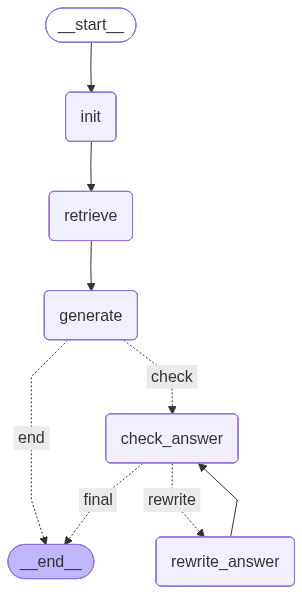

In [15]:
g = StateGraph(State)
g.add_node("init", initialize_state)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_node('check_answer',check_answer_quality)
g.add_node('rewrite_answer',rewrite_answer)



g.add_edge(START, "init")
g.add_edge('init', "retrieve")
g.add_edge("retrieve", "generate")

# ✅ ONLY conditional edges here
g.add_conditional_edges(
    "generate",
    decide_after_generate,
    {
        "end": END,
        "check": 'check_answer'
       
    }
)


# ✅ ONLY conditional edges here
g.add_conditional_edges(
    "check_answer",
    decide_after_check,
    {
        "rewrite": "rewrite_answer",
        "final": END
    }
)
# ✅ Loop back after rewrite
g.add_edge("rewrite_answer", "check_answer")

app = g.compile()

app

In [16]:
# 5) Run
res = app.invoke({"question": "What is a optimization."})
print(res["answer"])

the process of maximizing or minimizing the system output by adjusting the system parameters


In [17]:
res['regenerated'],res['verdict'],res['final_status']

(False, 'Supported', 'clean')

In [18]:
# 5) Run
res = app.invoke({"question": "WHat is a Machine Learning."})
print(res["answer"])

I don't know


In [19]:
res['regenerated'],res['verdict'],res['final_status']

(False, 'Not_Sure', 'not_in_docs')

In [20]:
def format_output(state):
    
    status = state["final_status"]

    if status == "clean":
        return f"""
✅ Answer:
{state['answer']}
"""

    elif status == "corrected":
        return f"""
🔄 Making your answer hallucination free... ✓

✅ Answer:
{state['answer']}
"""

    elif status == "failed":
        return f"""
❌ We failed to get a hallucination free output.

The retrieved documents may not contain enough information 
to answer your question reliably.
"""

    elif status == "not_in_docs":
        return f"""
📄 The question you asked is not present in the document.
"""

In [21]:
res = app.invoke({"question": "What is a optimization."})

final_output = format_output(res)

print(final_output)


✅ Answer:
the process of maximizing or minimizing the system output by adjusting the system parameters



In [22]:
res = app.invoke({"question": "What is a Machine Learning."})

final_output = format_output(res)

print(final_output)


📄 The question you asked is not present in the document.

